# The Phase Plane (2D Nonlinear Systems)

Chapter 6 of *Nonlinear Dynamics and Chaos* transitions from the linear systems of Chapter 5 into the rich, geometric world of two-dimensional nonlinear systems. Because nonlinear equations are usually impossible to solve analytically, the chapter's premise is to extract the qualitative behavior of the system directly from the geometry of its vector field on the phase plane.

## 1. Applied Math: The Jacobian as an Interpretability Engine

In an LLM or World Model, the hidden state transition is $\mathbf{h}_{t+1} = \sigma(\mathbf{W}\mathbf{h}_t + \mathbf{b})$. To understand why a model "thinks" a certain way at state $\mathbf{h}^*$, we must calculate the **Local Jacobian**.

**The Derivation (Multi-variable Linearization)**
Given a 2D hidden state $\mathbf{h} = [h_1, h_2]^T$ and a transition function $\mathbf{f}(\mathbf{h})$, the Jacobian $\mathbf{J}$ is:

$$ \mathbf{J} = \begin{pmatrix} \frac{\partial f_1}{\partial h_1} & \frac{\partial f_1}{\partial h_2} \\ \frac{\partial f_2}{\partial h_1} & \frac{\partial f_2}{\partial h_2} \end{pmatrix} $$

If we evaluate this at a fixed point, the **Eigenvalues ($\lambda_1, \lambda_2$)** tell us the "Logic Type" of that neuron cluster:
- **Stable Node ($\lambda < 0$)**: This is a Concept Anchor. No matter what noisy tokens come in, the model stays locked on this meaning.
- **Saddle ($\lambda_1 < 0 < \lambda_2$)**: This is a Conditional Branch. It is stable for "Syntax" but unstable for "Semantics," allowing the model to pivot.

This justifies using Phase Plane math to "audit" a black-box model.

In [1]:
import torch

def toy_hidden_layer(h, W):
    return torch.tanh(W @ h)

# A random 2x2 weight matrix
W = torch.tensor([[1.5, -0.2], [0.1, 1.2]], requires_grad=True)
h_star = torch.tensor([0.8, 0.8], requires_grad=True) # A hypothesized fixed point

# Compute Jacobian automatically
J = torch.autograd.functional.jacobian(lambda x: toy_hidden_layer(x, W), h_star)

# Stability Analysis
eigenvalues = torch.linalg.eigvals(J)
print(f"Local Eigenvalues: {eigenvalues}")
# If Re(eigenvalues) < 1 (for discrete time) or < 0 (for continuous), it's a stable anchor.

Local Eigenvalues: tensor([0.5528+0.j, 0.5134+0.j])


## 2. Competitive Logic: The "Separatrix" as a Decision Boundary

Strogatz uses **Rabbits vs. Sheep (§6.4)** to show how species fight for dominance. In AGI, this is **Causal Selection**.

**Applied Math: Finding the "Ridge of Indecision"**
In the system $\dot{x} = x(3-x-2y), \dot{y} = y(2-x-y)$, the saddle point at $(1,1)$ has a Stable Manifold.

**The Math:** The eigenvector associated with the negative eigenvalue $\lambda_{stable}$ defines the **Separatrix**.

**The AGI Link:** This line is the model's uncertainty horizon. To reach AGI, we need models that can calculate their distance to the separatrix. If a model is close to the ridge, it should trigger a "Search" (like MCTS) instead of "Guessing" (next-token prediction).

## 3. The AGI Proposal: "Causal-Dynamical Guardrails"

**The Bottleneck:** LLMs hallucinate because their latent trajectories "drift" into physically impossible states. They don't have "walls" in their phase space.

**The Solution:** Topological Anchoring. We don't just train the model to predict; we train it to ensure that its trajectory is attracted to a "Causal Manifold."

In [2]:
import numpy as np

def causal_potential_gradient(s):
    """
    A 'Guardrail' function. Low energy = logically consistent state.
    Calculates the 'pull' back toward the manifold of truth.
    """
    # Example: Ensuring x^2 + y^2 = 1 (a unit-circle 'fact' manifold)
    dist = np.linalg.norm(s) - 1
    return -dist * (s / np.linalg.norm(s))

def anchored_step(s, action_velocity, dt=0.1, anchor_strength=0.5):
    """
    Proposed AGI Step:
    New State = (Standard Prediction) + (Dynamical Guardrail)
    """
    # 1. Standard prediction (the 'Statistical Parrot' part)
    s_next_raw = s + action_velocity * dt
    
    # 2. Causal Correction (The 'Physical Grounding' part)
    # We treat the 'Truth' as a stable attractor (Ch 6 logic)
    correction = causal_potential_gradient(s_next_raw)
    
    # 3. Combined update
    s_final = s_next_raw + anchor_strength * correction
    return s_final

## The Gradient Flow as a Dynamical System
 
In Deep Learning, we do not just "update weights." We are evolving a state $\theta$ in a high-dimensional phase space. Continuous-time Gradient Descent is defined by the ODE:
 
$$\dot{\theta} = -\nabla L(\theta)$$
 
### The Applied Math: Hessian as the Jacobian
 
To understand if a fixed point (critical point where $\nabla L = 0$) is a usable minimum or a problematic plateau, we must linearize the flow. The **Jacobian of the Gradient Flow** is exactly the negative **Hessian matrix**:
 
$$J(-\nabla L) = -\mathbf{H}(\theta)$$
 
According to **Strogatz §6.3**, the stability of $\theta^*$ is determined by the eigenvalues of this Jacobian:
 
- **Stable Node (Local Minimum):** All eigenvalues of $\mathbf{H}(\theta^*)$ are positive. The "Phase Fluid" of parameters drains into this sink.
- **Saddle Point:** $\mathbf{H}(\theta^*)$ has both positive and negative eigenvalues.
  - **The AGI Problem:** In high dimensions, most critical points are saddles. The **Unstable Manifold** of these saddles causes diverging parameter trajectories — colloquially associated with "Gradient Explosion" or "Divergence" — while the **Stable Manifold** (which in 2D coincides with the Separatrix) is the set of trajectories flowing *into* the saddle, creating the plateaus where learning stalls.
 
> **Note:** Gradient explosion in RNNs is technically caused by eigenvalues of the *recurrent weight Jacobian* (a product across time steps), not the loss-landscape saddle per se. The unstable manifold framing here captures the same divergence geometry in parameter space.
 

Jacobian Eigenvalues at Saddle: tensor([-2.,  2.])


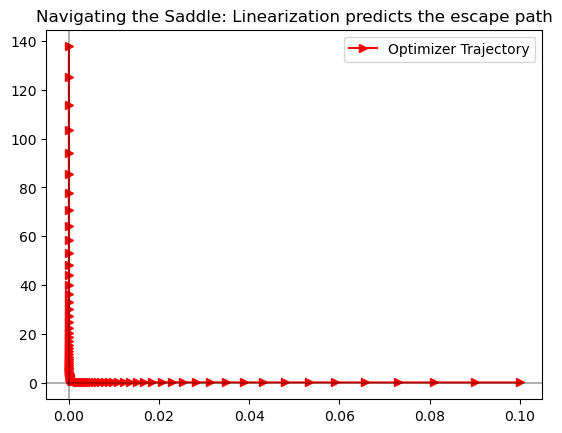

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def loss_surface(theta):
    # A saddle point at (0,0): L = x^2 - y^2
    return theta[0]**2 - theta[1]**2

def get_gradient_flow(theta):
    theta_val = theta.detach().requires_grad_(True)
    loss = loss_surface(theta_val)
    grad = torch.autograd.grad(loss, theta_val)[0]
    return -grad  # The velocity f(theta)

# 1. Linearization at the Saddle (0,0)
theta_star = torch.tensor([0.0, 0.0], requires_grad=True)
# The Jacobian of the negative gradient is the negative Hessian
H = torch.autograd.functional.hessian(loss_surface, theta_star)
J = -H

eigenvals = torch.linalg.eigvals(J)
print(f"Jacobian Eigenvalues at Saddle: {eigenvals.real}")
# Output: [-2, 2] -> One stable direction (x), one unstable (y).

# 2. Simulation of "Parameter Drift"
dt = 0.05
theta = torch.tensor([0.1, 0.01])  # Start slightly off-center
traj = [theta.numpy().copy()]

for _ in range(100):
    v = get_gradient_flow(theta)
    theta = theta + v * dt
    traj.append(theta.numpy().copy())

traj = np.array(traj)
plt.plot(traj[:, 0], traj[:, 1], 'r->', label="Optimizer Trajectory")
plt.axhline(0, color='k', alpha=0.3)
plt.axvline(0, color='k', alpha=0.3)
plt.title("Navigating the Saddle: Linearization predicts the escape path")
plt.legend()
plt.show()

## Associative Memory: Semantic Capture via Basins of Attraction
 
In LLMs, the latent space is a **Phase Plane** where concepts are **Stable Nodes**. An ambiguous prompt is an initial condition $x_0$ placed near a **Separatrix**.
 
### The Applied Math: The "Tilt" of Context
 
We model the latent state $\mathbf{z}$ as a nonlinear flow. "Context" (like an additional prompt token) acts as a forcing parameter $\mathbf{c}$ that shifts the nullclines:
 
$$\dot{\mathbf{z}} = \mathbf{f}(\mathbf{z}) + \mathbf{c}$$
 
- **Without Context:** The system is symmetric. The saddle point (separatrix) sits exactly between "Bank (Finance)" and "Bank (River)."
- **With Context:** Adding $\mathbf{c}$ (e.g., the vector for "money") creates an **imperfect pitchfork bifurcation** — the symmetry of the bistable potential is broken, the separatrix shifts, and the $x_0$ that was once ambiguous is now deep inside the "Finance" basin.
 
> **Bifurcation note:** The system $\dot{z} = z - z^3 + c$ is a pitchfork bifurcation with symmetry-breaking imperfection $c$, not a transcritical bifurcation. A transcritical bifurcation involves two fixed points exchanging stability (e.g. $\dot{x} = rx - x^2$). Here, $c \neq 0$ simply tilts the potential well $V(z) = -z^2/2 + z^4/4$, displacing the saddle and shifting the basin boundary.

In [4]:
import numpy as np

def semantic_flow(z, context=0.0):
    # z[0] is the 'Finance' axis, z[1] is 'River'
    # Bistable system: z - z^3 has stable FPs at ±1, unstable at 0
    # Context 'tilts' the potential, breaking symmetry
    dz1 = z[0] - z[0]**3 + context
    dz2 = z[1] - z[1]**3 - context
    return np.array([dz1, dz2])

# Plotting the 'Choice' between two semantic basins
z0 = np.array([0.05, 0.05])  # Slightly ambiguous start
context_val = 0.2             # 'Money' context pushes toward z1 (Finance)

# Numerical integration (Euler)
z = z0.copy()
path = [z.copy()]
for _ in range(50):
    z = z + semantic_flow(z, context_val) * 0.1
    path.append(z.copy())

path = np.array(path)
print(f"Final Semantic State: {path[-1]}")
# z[0] converges near +1 (Finance basin), z[1] near -1 (River basin suppressed)

Final Semantic State: [ 1.08800735 -1.08790517]


## Dynamic Basins and Separatrix Safety
 
For AGI, the "Fixed Points" cannot be static. We require **Non-Autonomous Systems** where $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}, t)$.
 
### The Applied Math: Separatrix Monitoring
 
A self-driving AGI calculates the **Stable Manifold** of a "Collision Fixed Point."
 
- **Collision Basin:** The set of states where physics makes a crash inevitable.
- **The Separatrix:** The high-dimensional "ridge" separating safety from catastrophe.
- **Mathematical Guardrail:** The AGI must compute the **Distance to the Separatrix**. If the Jacobian at the current state $J(\mathbf{x}_t)$ shows a growing eigenvalue in the direction of the "Collision Node," the agent must apply a counter-force to shift the nullclines.

In [5]:
# This represents a "World Model" that monitors the proximity to a forbidden basin.
import numpy as np

def check_safety_margin(state, world_model_jacobian):
    """
    AGI Safety Metric: Proximity to the Unstable Manifold.
    If the state is nearing a separatrix, the 'Entropy of Action' increases.
    """
    evals, evecs = np.linalg.eig(world_model_jacobian)

    # Identify the 'dangerous' eigenvalue (pointing toward a collision node)
    unstable_idx = np.argmax(evals.real)
    danger_direction = evecs[:, unstable_idx]

    # Project current velocity onto the danger direction
    # This gives the signed rate of approach toward the separatrix
    return danger_direction

# Implementation in a World Model:
# s_next = s_current + f(s, a)
# IF distance_to_separatrix(s_next) < threshold:
#    REJECT action 'a' -> Cross-over into the 'Collision Basin' is imminent.